**Task 2: Predict Future Stock Prices (Short-Term)**

**Objective:**

 Use historical stock data to predict the next day's closing price.

**Dataset:**

 Stock market data from Yahoo Finance (retrieved using the yfinance Python library)

In [50]:
# ===============================================
# Task 2: Predict Future Stock Prices (Short-Term)
# ===============================================

# Importing required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
# -----------------------------
# Step 1: Load Stock Data
# -----------------------------
# Select a stock (e.g., Apple - ticker 'AAPL')
stock_ticker = 'AAPL'
data = yf.download(stock_ticker, start='2020-01-01', end='2026-01-31')

# Display first 5 rows
data.head()

/tmp/ipython-input-263/3844338434.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_ticker, start='2020-01-01', end='2026-01-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400497,72.460761,71.156659,71.409763,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [52]:
# -----------------------------
# Step 2: Explore & Preprocess Data
# -----------------------------
# Check for missing values
print("Missing values:\n", data.isnull().sum())

# Use only relevant features: Open, High, Low, Volume to predict Close
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

X = data[features]
y = data[target]

# Shift target by -1 to predict next day's closing price
y = y.shift(-1)
X = X[:-1]
y = y[:-1]

Missing values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [53]:
# -----------------------------
# Step 3: Split Data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [54]:
# -----------------------------
# Step 4: Train Model
# -----------------------------
# Option 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Option 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [55]:
# -----------------------------
# Step 5: Evaluate Models
# -----------------------------
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("-"*30)

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression Performance:
RMSE: 4.32
R^2 Score: 0.97
------------------------------
Random Forest Performance:
RMSE: 19.28
R^2 Score: 0.42
------------------------------


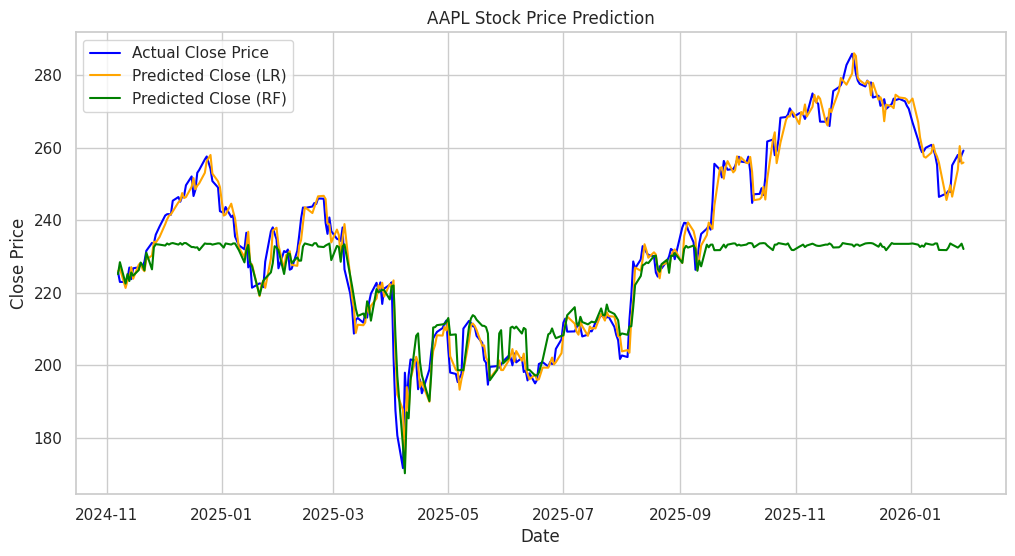

In [56]:
# -----------------------------
# Step 6: Plot Predictions
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual Close Price', color='blue')
plt.plot(y_test.index, y_pred_lr, label='Predicted Close (LR)', color='orange')
plt.plot(y_test.index, y_pred_rf, label='Predicted Close (RF)', color='green')
plt.title(f'{stock_ticker} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

**Insights:**
- The model predicts next-day closing price based on Open, High, Low, and Volume.
- Random Forest usually captures non-linear trends better than Linear Regression.
- Observing actual vs predicted plots can help understand how well the model follows market trends.
- This can be extended with more features (technical indicators) or advanced models (LSTM, XGBoost).